In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))

In [4]:
twomass = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/2mass_psc/2mass_psc_j_12-dr9.fits'))

Doubly matched objects = 2359
Final matched objects = 842110


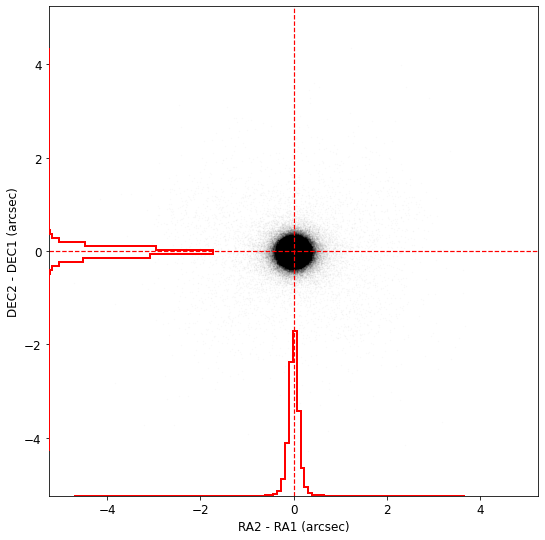

0.34918677476497245
0.9934209206936051


In [5]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord.match_coord(twomass['RA'], twomass['DEC'], tycho2['RA'], tycho2['DEC'], priority2=-tycho2['VTmag'], search_radius=5., plot_q=True)
print(len(idx1)/len(twomass))
print(len(idx1)/len(tycho2))

In [6]:
mask_missing = np.full(len(tycho2), True)
mask_missing[idx2] = False
print(np.sum(mask_missing), np.sum(mask_missing)/len(tycho2))

5577 0.006579079306394931


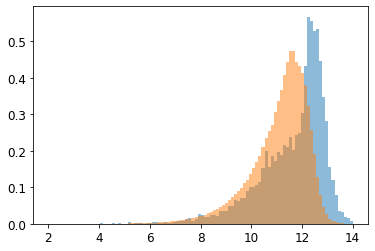

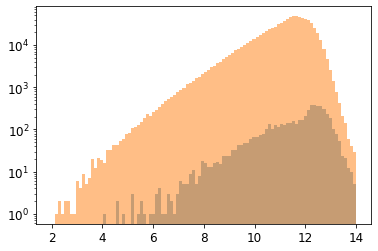

In [7]:
plt.hist(tycho2['VTmag'][mask_missing], 100, range=(2, 14), density=True, alpha=0.5, log=False)
plt.hist(tycho2['VTmag'][~mask_missing], 100, range=(2, 14), density=True, alpha=0.5, log=False)
plt.show()

plt.hist(tycho2['VTmag'][mask_missing], 100, range=(2, 14), density=False, alpha=0.5, log=True)
plt.hist(tycho2['VTmag'][~mask_missing], 100, range=(2, 14), density=False, alpha=0.5, log=True)
plt.show()

In [8]:
tycho2 = tycho2[idx2]
twomass = twomass[idx1]

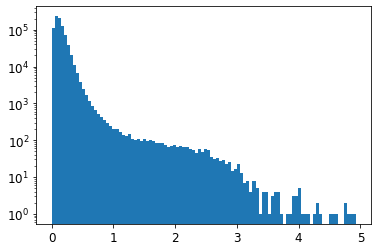

In [9]:
plt.hist(d2d, 100, log=True);

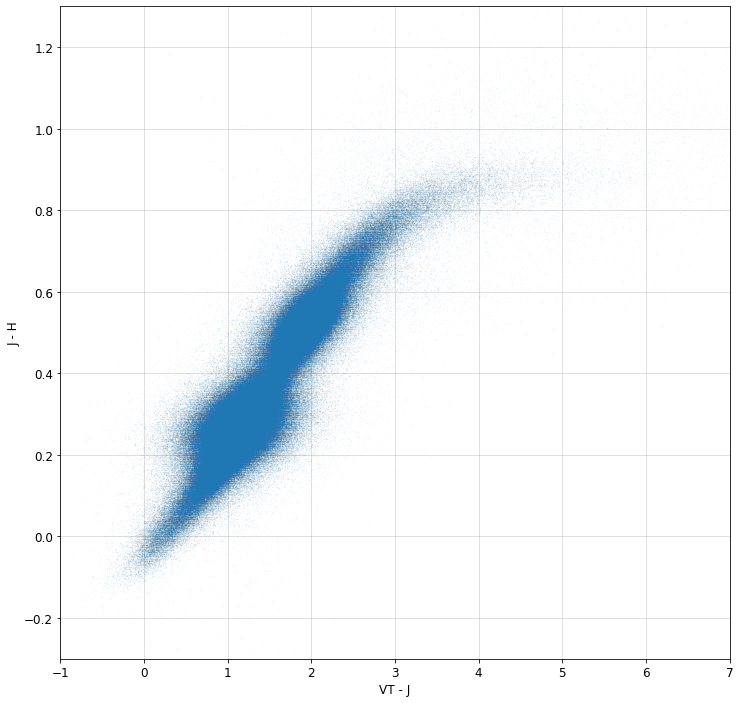

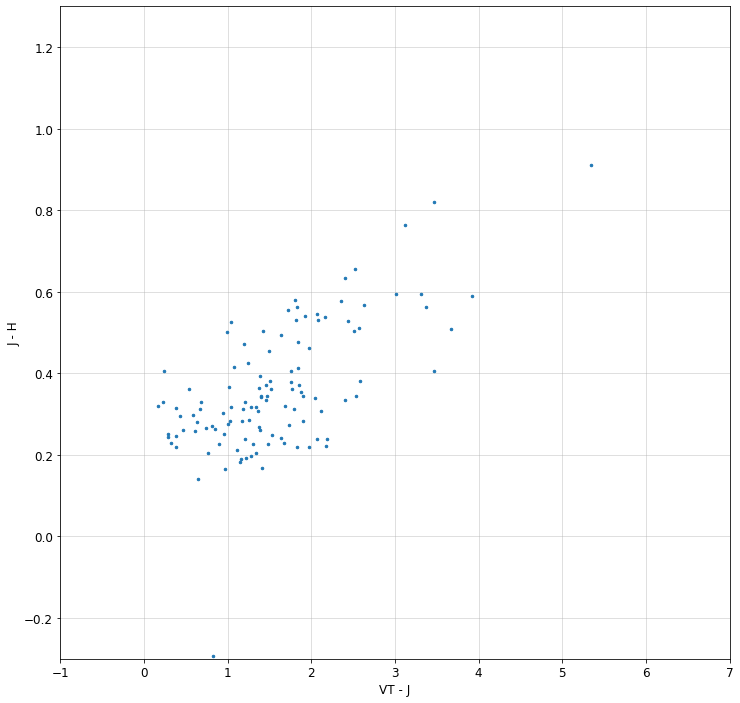

In [10]:
mask = d2d>3

plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag'])[~mask], (twomass['Jmag'] - twomass['Hmag'])[~mask], '.', ms=0.1, alpha=0.5)
plt.xlabel('VT - J')
plt.ylabel('J - H')
plt.axis([-1, 7, -0.3, 1.3])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag'])[mask], (twomass['Jmag'] - twomass['Hmag'])[mask], '.', ms=5, alpha=1)
plt.xlabel('VT - J')
plt.ylabel('J - H')
plt.axis([-1, 7, -0.3, 1.3])
plt.grid(alpha=0.5)
plt.show()